In [ ]:
import pickle as pkl 
import numpy as np  
import matplotlib.pyplot as plt
from pymer4.models import Lmer
from matplotlib import patches
from matplotlib.transforms import Bbox
from utils import boxplot_2x2, visualize_trajectory_3d

In [34]:
levels = pkl.load(open('data/LevelsFinal.pkl','rb'))
players_data = pkl.load(open('data/ResultsPilot.pkl','rb'))
first_decision_point_data = pkl.load(open('data/ResultsFirstDecision.pkl','rb'))
all_decision_points_data = pkl.load(open('data/ResultsAllDecisions.pkl','rb'))

subject_num = len(players_data)

Linear mixed model for the probability of choosing the risky jump at the first decision point

In [ ]:
model = Lmer(f"ChoiceSmall ~ SmallShorter * SmallSmallerAngle + (1|SubjectID)", data=first_decision_point_data, family='binomial')
result_model = model.fit(factors={'SmallShorter': ["0", "1"], 'SmallSmallerAngle': ["0","1"]})
random_effects = model.ranef.to_numpy()
random_effects_variance = model.ranef_var['Var']['SubjectID']

display(result_model)

# Pairwise comparisons
marginal_estimates, first_decision_comparisons = model.post_hoc(
    marginal_vars=["SmallSmallerAngle", "SmallShorter"], p_adjust="tukey"
)


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: ChoiceSmall~SmallShorter*SmallSmallerAngle+(1|SubjectID)

Family: binomial	 Inference: parametric

Number of observations: 1549	 Groups: {'SubjectID': 40.0}

Log-likelihood: -889.460 	 AIC: 1788.921

Random effects:

                  Name    Var    Std
SubjectID  (Intercept)  0.719  0.848

No random effect correlations specified

Fixed effects:



c:\Users\david\OneDrive\Desktop\work\projects\Planning-While-Acting\.conda\Lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),-0.787,-1.132,-0.441,0.176,0.455,0.322,0.643,0.313,0.244,0.391,-4.465,0.0,***
SmallShorter1,1.082,0.773,1.391,0.158,2.950,2.166,4.018,0.747,0.684,0.801,6.862,0.0,***
SmallSmallerAngle1,0.721,0.405,1.037,0.161,2.057,1.500,2.821,0.673,0.600,0.738,4.475,0.0,***
SmallShorter1:SmallSmallerAngle1,0.852,0.377,1.326,0.242,2.344,1.459,3.767,0.701,0.593,0.790,3.519,0.0,***


P-values adjusted by tukey method for family of 6 estimates


Linear mixed model for the probability of choosing the risky jump at all decision points

In [ ]:
# Stessa analizi, ma per tutti i decision points
model = Lmer(f"ChoiceSmall ~ SmallShorter * SmallSmallerAngle + (1|SubjectID)", data=all_decision_points_data, family='binomial')
result_model = model.fit(factors={'SmallShorter': ["0", "1"], 'SmallSmallerAngle': ["0","1"]})
random_effects = model.ranef.to_numpy()
random_effects_variance = model.ranef_var['Var']['SubjectID']

display(result_model)

# Pairwise comparisons
marginal_estimates, all_decisions_comparisons = model.post_hoc(
    marginal_vars=["SmallSmallerAngle", "SmallShorter"], p_adjust="tukey"
)


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: ChoiceSmall~SmallShorter*SmallSmallerAngle+(1|SubjectID)

Family: binomial	 Inference: parametric

Number of observations: 4778	 Groups: {'SubjectID': 40.0}

Log-likelihood: -2550.341 	 AIC: 5110.682

Random effects:

                  Name    Var    Std
SubjectID  (Intercept)  0.478  0.691

No random effect correlations specified

Fixed effects:



c:\Users\david\OneDrive\Desktop\work\projects\Planning-While-Acting\.conda\Lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),-1.463,-1.747,-1.178,0.145,0.232,0.174,0.308,0.188,0.148,0.235,-10.081,0.000,***
SmallShorter1,1.665,1.424,1.905,0.123,5.285,4.155,6.720,0.841,0.806,0.870,13.575,0.000,***
SmallSmallerAngle1,1.014,0.786,1.242,0.116,2.757,2.195,3.462,0.734,0.687,0.776,8.728,0.000,***
SmallShorter1:SmallSmallerAngle1,0.358,0.064,0.651,0.150,1.430,1.066,1.918,0.588,0.516,0.657,2.387,0.017,*


P-values adjusted by tukey method for family of 6 estimates


In [30]:
# Store the significance values for the various comparisons
first_decision_comparisons_sig = [
    (0,1, first_decision_comparisons['P-val'].iloc[0]),
    (0,2, first_decision_comparisons['P-val'].iloc[1]),
    (0,3, first_decision_comparisons['P-val'].iloc[2]),
    (1,3, first_decision_comparisons['P-val'].iloc[4]),
    (2,3, first_decision_comparisons['P-val'].iloc[5]),
]

all_decisions_comparisons_sig = [
    (0,1, all_decisions_comparisons['P-val'].iloc[0]),
    (0,2, all_decisions_comparisons['P-val'].iloc[1]),
    (0,3, all_decisions_comparisons['P-val'].iloc[2]),
    (1,2, all_decisions_comparisons['P-val'].iloc[3]),
    (1,3, all_decisions_comparisons['P-val'].iloc[4]),
    (2,3, all_decisions_comparisons['P-val'].iloc[5]),
]

# The factor combinations used in the analysis (to extract the data for the boxplot)
factors_risky_jump = [
    {'SmallShorter':False, 'SmallSmallerAngle':False}, 
    {'SmallShorter':False, 'SmallSmallerAngle':True},
    {'SmallShorter':True, 'SmallSmallerAngle':False}, 
    {'SmallShorter':True, 'SmallSmallerAngle':True}
]

# Levels chosen for the examples
level_inds = [0,1,14,15]

### Figure 2 - probability of risky jump at first and all decision points + subjects' trajectories in 4 example maps (one for each factors combination)

[(0, 1, np.float64(0.0)), (0, 2, np.float64(0.0)), (0, 3, np.float64(0.0)), (1, 3, np.float64(0.0)), (2, 3, np.float64(0.0))]
[(0, 1, np.float64(0.0)), (0, 2, np.float64(0.0)), (0, 3, np.float64(0.0)), (1, 2, np.float64(0.0)), (1, 3, np.float64(0.0)), (2, 3, np.float64(0.0))]


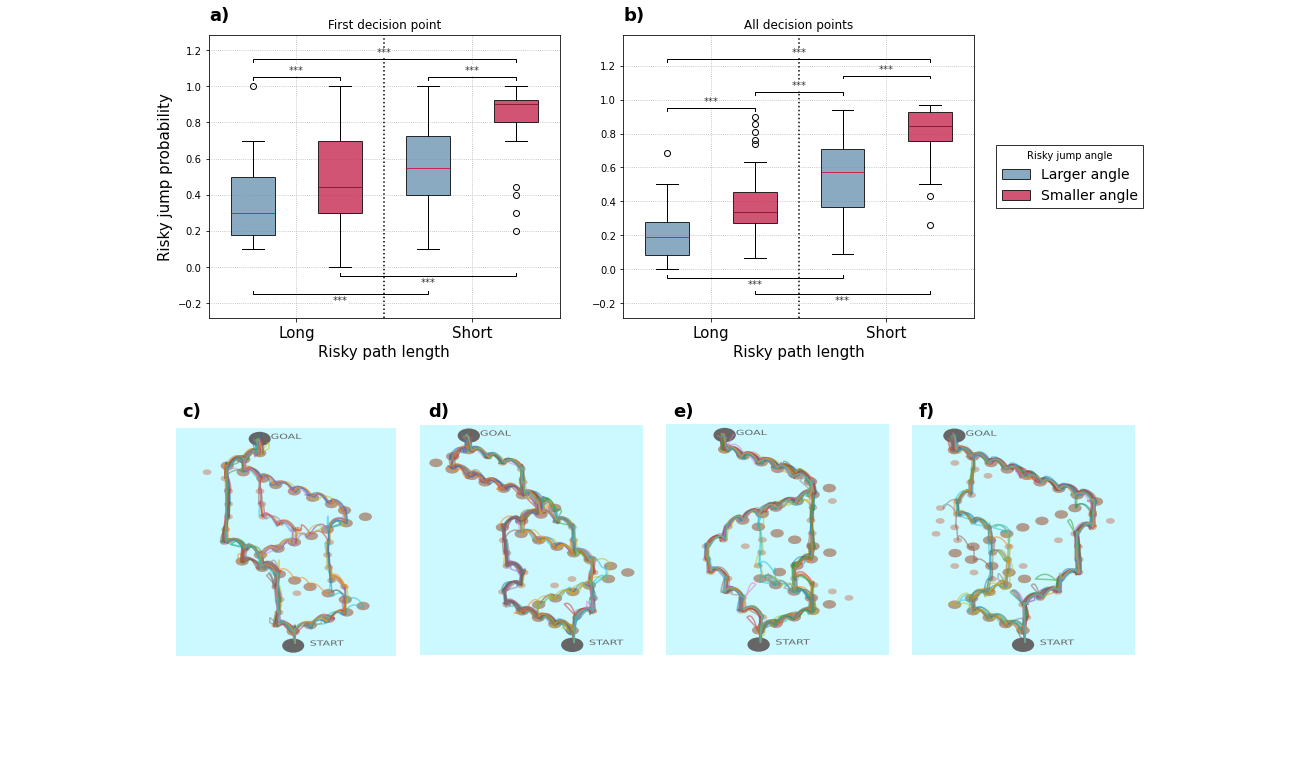

In [32]:
color_blue_pastel = np.array([108, 149, 178])/255
color_bordeaux = np.array([199, 41, 83])/255

fig = plt.figure(figsize=(16,11), dpi=72)
gs = fig.add_gridspec(2,5, width_ratios=(0.225,0.225,0.225,0.225,0.1), wspace=0.5, hspace=0.15)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 0], projection='3d', computed_zorder=False)
ax4 = fig.add_subplot(gs[1, 1], projection='3d', computed_zorder=False)
ax5 = fig.add_subplot(gs[1, 2], projection='3d', computed_zorder=False)
ax6 = fig.add_subplot(gs[1, 3], projection='3d', computed_zorder=False)

axes = [ax1, ax2, ax3, ax4, ax5, ax6]

box_colors = [color_blue_pastel, color_bordeaux]
median_colors = [color_bordeaux, color_bordeaux * 0.7]
xlabels = ['Long','Short']
legend_labels = ['Larger angle', 'Smaller angle']


# First decision point boxplot
ax = axes[0]

boxplot_2x2(ax, first_decision_point_data, 'ChoiceSmall', factors_risky_jump, first_decision_comparisons_sig, box_colors, median_colors, xlabels, only_top_lines=False)
plt.xlabel('Risky path length', fontsize=15)
plt.ylabel('Risky jump probability', fontsize=15)

plt.title('First decision point')

# All decision points boxplot
ax = axes[1]

boxplot_2x2(ax, all_decision_points_data, 'ChoiceSmall', factors_risky_jump, all_decisions_comparisons_sig, box_colors, median_colors, xlabels, only_top_lines=False)
plt.xlabel('Risky path length', fontsize=15)
plt.title('All decision points')

# 3D example trajectories

axis_scaling = 0.35
letters = ['c','d','e','f']
for i in range(4):
    plt.sca(axes[i+2])

    level = levels[level_inds[i]]
    trajectories = []

    for subject_ind in range(subject_num):
        trajectories.append(players_data[subject_ind].level_results[level.level_name].trajectory)

    decision_point_ids = [d.platform.id for d in level.decision_points]
    visualize_trajectory_3d(trajectories, level)

    ax = plt.gca()
    pos = ax.get_position()

    # Adjust the position to make it larger (increase the width and height)
    new_pos = [pos.x0 - axis_scaling/2 + (i - 1.5)/1.5 * 0.05 + 0.05, pos.y0 - axis_scaling/2 - 0.05, pos.width + axis_scaling, pos.height + axis_scaling]

    # Set the new position
    ax.set_position(new_pos)
        
    ax_2d = fig.add_axes(new_pos)  # Add a new axis in the same position
    ax_2d.set_xticks([])
    ax_2d.set_yticks([])
    ax_2d.set_frame_on(False)  
    ax_2d.text(0.32, 0.8, f'{letters[i]})', transform=ax_2d.transAxes, size=18, weight='bold')


legend_gs = gs[0,4].subgridspec(3, 1, wspace=0, hspace=0)
ax_leg = fig.add_subplot(legend_gs[1,0])
plt.sca(ax_leg)

ax_leg.spines.top.set_visible(False)
ax_leg.spines.bottom.set_visible(False)
ax_leg.spines.left.set_visible(False)
ax_leg.spines.right.set_visible(False)
ax_leg.set(xticks=[], yticks=[])

patch_1 = patches.Patch(facecolor=box_colors[0], alpha=0.8, edgecolor='k', label = legend_labels[0])
patch_2 = patches.Patch(facecolor=box_colors[1], alpha=0.8, edgecolor='k',  label = legend_labels[1])
plt.legend(handles = [patch_1, patch_2], loc='center', fontsize=14, fancybox=False, edgecolor='k',
           title='Risky jump angle', alignment='center')

for i,l in enumerate(['a','b']):
    axes[i].text(0, 1.05, f'{l})', transform=axes[i].transAxes, size=18, weight='bold')


bbox = Bbox.from_bounds(-57 * 0.0138 + 1.7,-20 * 0.0138 + 0.5,1226 * 0.0138 - 2,724 * 0.0138)
